# Acne Detection Multi-Class using YOLOv8

Notebook này thực hiện **phát hiện mụn đa lớp** (multi-class acne detection) sử dụng YOLOv8.

## 🎯 Mục tiêu
- **Bài toán**: Multi-class acne detection với 6 loại mụn
- **Classes**: blackheads, dark spot, nodules, papules, pustules, whiteheads
- **Model**: YOLOv8 (nano, small, medium)
- **Dataset**: Acne-20 (Roboflow)

## 📋 Workflow
1. Setup và Import Libraries
2. Phân tích dữ liệu (Data Analysis)
3. Training với YOLOv8
4. Đánh giá mô hình (Evaluation)
5. Inference và Visualization


In [1]:
# Install required packages
%pip install ultralytics opencv-python matplotlib numpy tqdm pandas seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Check device availability
import torch

# Check if MPS (Metal Performance Shaders) is available for Mac
if torch.backends.mps.is_available():
    device = 'mps'
    print("✅ GPU (MPS) is available! Using GPU for training.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("✅ CUDA GPU is available!")
else:
    device = 'cpu'
    print("⚠️ Using CPU (slower). Consider using GPU if available.")

print(f"\nDevice selected: {device}")
print(f"PyTorch version: {torch.__version__}")


✅ GPU (MPS) is available! Using GPU for training.

Device selected: mps
PyTorch version: 2.9.0


In [3]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import random
import yaml
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1. Cấu hình Dataset


In [21]:
# Đường dẫn dataset
dataset_path = "data-2"
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Kiểm tra dataset có tồn tại không
if not os.path.exists(data_yaml_path):
    print(f"⚠️ Dataset not found at {dataset_path}")
    print("Please ensure the dataset is in the correct location.")
else:
    print(f"✅ Dataset found at: {dataset_path}")
    
    # Đọc data.yaml
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    print(f'\n📋 Dataset Config:')
    print(f'   Classes: {data_config.get("nc", "N/A")}')
    print(f'   Class names: {data_config.get("names", "N/A")}')
    
    # Đường dẫn các thư mục
    train_path = os.path.join(dataset_path, 'train')
    val_path = os.path.join(dataset_path, 'valid')
    test_path = os.path.join(dataset_path, 'test')
    
    # Đếm số lượng
    train_images = os.listdir(os.path.join(train_path, 'images')) if os.path.exists(os.path.join(train_path, 'images')) else []
    val_images = os.listdir(os.path.join(val_path, 'images')) if os.path.exists(os.path.join(val_path, 'images')) else []
    test_images = os.listdir(os.path.join(test_path, 'images')) if os.path.exists(os.path.join(test_path, 'images')) else []
    
    print(f'\n📊 Dataset Statistics:')
    print(f'   Training images: {len(train_images)}')
    print(f'   Validation images: {len(val_images)}')
    print(f'   Test images: {len(test_images)}')
    print(f'   Total images: {len(train_images) + len(val_images) + len(test_images)}')
    
    # Lưu class names
    class_names = data_config.get("names", [])
    num_classes = data_config.get("nc", 0)


✅ Dataset found at: data-2

📋 Dataset Config:
   Classes: 5
   Class names: ['blackheads', 'cyst', 'papules', 'pustules', 'whiteheads']

📊 Dataset Statistics:
   Training images: 422
   Validation images: 162
   Test images: 78
   Total images: 662


## 2. Phân tích Dữ liệu (Data Analysis)


In [22]:
# Phân tích độ cân bằng dữ liệu
def analyze_data_balance(image_dir, label_dir, split_name="Train", class_names=None):
    """Analyze class distribution and data balance"""
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    
    class_counts = Counter()
    images_with_objects = 0
    images_without_objects = 0
    total_objects = 0
    objects_per_image = []
    
    for label_file in label_files:
        label_path = os.path.join(label_dir, label_file)
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        if len(lines) == 0:
            images_without_objects += 1
            continue
        
        images_with_objects += 1
        num_objects = len(lines)
        total_objects += num_objects
        objects_per_image.append(num_objects)
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(parts[0])
                class_counts[cls] += 1
    
    print(f"\n📊 {split_name} Set Analysis:")
    print(f"   Total images: {len(label_files)}")
    print(f"   Images with objects: {images_with_objects}")
    print(f"   Images without objects: {images_without_objects}")
    print(f"   Total objects: {total_objects}")
    print(f"   Avg objects per image: {total_objects / images_with_objects if images_with_objects > 0 else 0:.2f}")
    
    print(f"\n📈 Class Distribution ({split_name}):")
    if class_names:
        for cls_id in sorted(class_counts.keys()):
            cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
            count = class_counts[cls_id]
            percentage = (count / total_objects * 100) if total_objects > 0 else 0
            print(f"   {cls_name}: {count} ({percentage:.2f}%)")
    else:
        for cls_id in sorted(class_counts.keys()):
            count = class_counts[cls_id]
            percentage = (count / total_objects * 100) if total_objects > 0 else 0
            print(f"   Class {cls_id}: {count} ({percentage:.2f}%)")
    
    return class_counts, objects_per_image

# Phân tích train, val, test sets
train_label_dir = os.path.join(train_path, 'labels')
val_label_dir = os.path.join(val_path, 'labels')
test_label_dir = os.path.join(test_path, 'labels')

train_class_counts, train_objects_per_img = analyze_data_balance(
    os.path.join(train_path, 'images'), train_label_dir, "Train", class_names
)
val_class_counts, val_objects_per_img = analyze_data_balance(
    os.path.join(val_path, 'images'), val_label_dir, "Validation", class_names
)
test_class_counts, test_objects_per_img = analyze_data_balance(
    os.path.join(test_path, 'images'), test_label_dir, "Test", class_names
)



📊 Train Set Analysis:
   Total images: 422
   Images with objects: 422
   Images without objects: 0
   Total objects: 890
   Avg objects per image: 2.11

📈 Class Distribution (Train):
   blackheads: 178 (20.00%)
   cyst: 178 (20.00%)
   papules: 178 (20.00%)
   pustules: 178 (20.00%)
   whiteheads: 178 (20.00%)

📊 Validation Set Analysis:
   Total images: 162
   Images with objects: 162
   Images without objects: 0
   Total objects: 695
   Avg objects per image: 4.29

📈 Class Distribution (Validation):
   blackheads: 36 (5.18%)
   cyst: 42 (6.04%)
   papules: 268 (38.56%)
   pustules: 161 (23.17%)
   whiteheads: 188 (27.05%)

📊 Test Set Analysis:
   Total images: 78
   Images with objects: 78
   Images without objects: 0
   Total objects: 538
   Avg objects per image: 6.90

📈 Class Distribution (Test):
   blackheads: 34 (6.32%)
   cyst: 46 (8.55%)
   papules: 185 (34.39%)
   pustules: 129 (23.98%)
   whiteheads: 144 (26.77%)


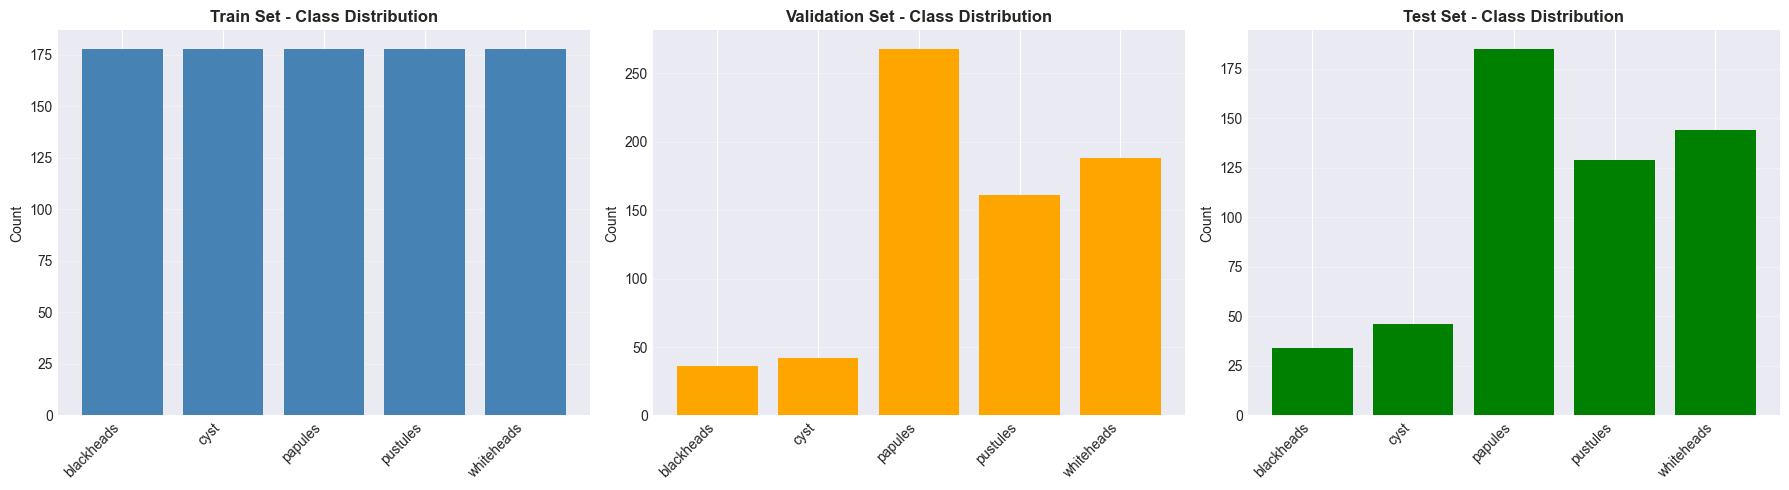

In [23]:
# Visualization: Class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train set
train_classes = sorted(train_class_counts.keys())
train_counts = [train_class_counts[cls] for cls in train_classes]
train_labels = [class_names[cls] if cls < len(class_names) else f"Class {cls}" for cls in train_classes]

axes[0].bar(range(len(train_classes)), train_counts, color='steelblue')
axes[0].set_xticks(range(len(train_classes)))
axes[0].set_xticklabels(train_labels, rotation=45, ha='right')
axes[0].set_title('Train Set - Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Validation set
val_classes = sorted(val_class_counts.keys())
val_counts = [val_class_counts[cls] for cls in val_classes]
val_labels = [class_names[cls] if cls < len(class_names) else f"Class {cls}" for cls in val_classes]

axes[1].bar(range(len(val_classes)), val_counts, color='orange')
axes[1].set_xticks(range(len(val_classes)))
axes[1].set_xticklabels(val_labels, rotation=45, ha='right')
axes[1].set_title('Validation Set - Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

# Test set
test_classes = sorted(test_class_counts.keys())
test_counts = [test_class_counts[cls] for cls in test_classes]
test_labels = [class_names[cls] if cls < len(class_names) else f"Class {cls}" for cls in test_classes]

axes[2].bar(range(len(test_classes)), test_counts, color='green')
axes[2].set_xticks(range(len(test_classes)))
axes[2].set_xticklabels(test_labels, rotation=45, ha='right')
axes[2].set_title('Test Set - Class Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


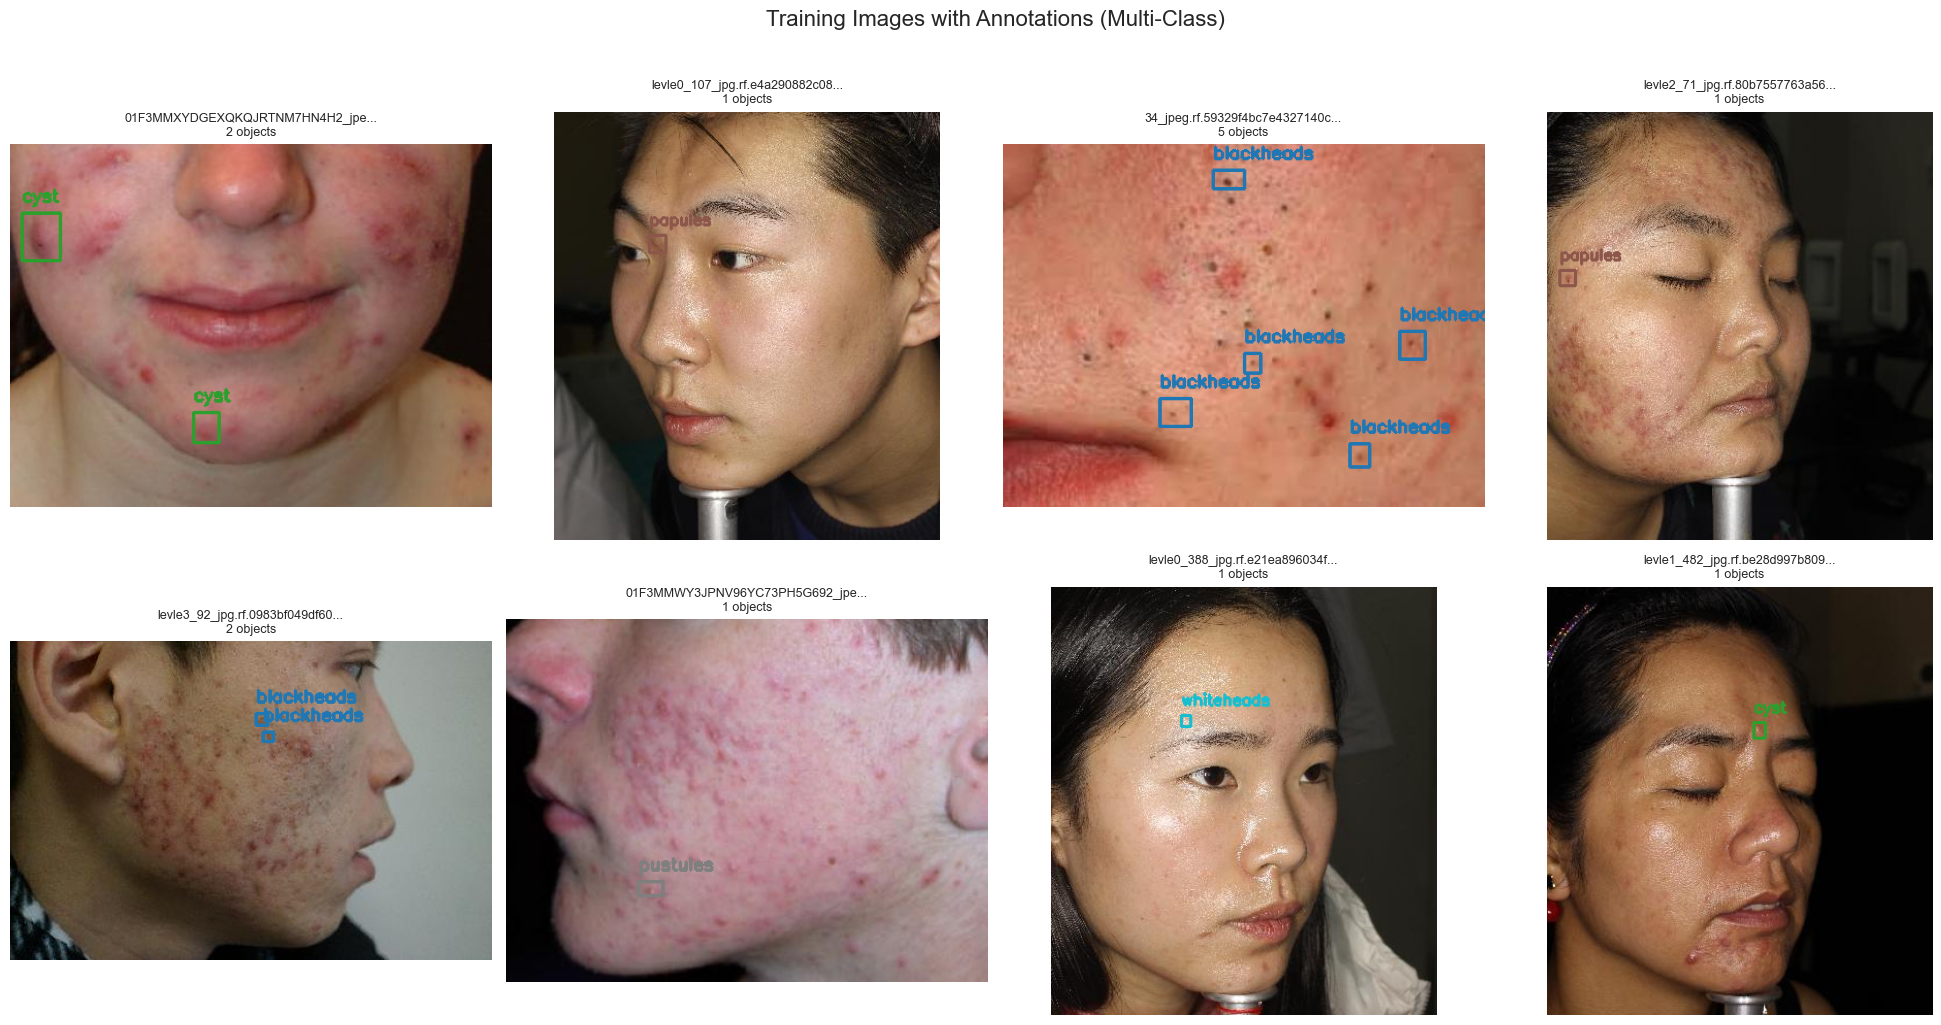

In [24]:
# Visualization: Sample images with annotations
def visualize_images_with_labels(image_dir, label_dir, num_samples=8, title="Sample Images", class_names=None):
    """Visualize images with bounding boxes"""
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if len(image_files) == 0:
        print(f"⚠️ No images found in {image_dir}")
        return
    
    selected_images = random.sample(image_files, min(num_samples, len(image_files)))
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    # Color map for different classes
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    
    for i, img_file in enumerate(selected_images):
        img_path = os.path.join(image_dir, img_file)
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(label_dir, label_file)
        
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        
        # Read labels and draw boxes
        num_objects = 0
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            num_objects = len(lines)
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    # Convert to pixel coordinates
                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)
                    
                    # Get color for this class
                    color = (colors[cls][:3] * 255).astype(int).tolist()
                    
                    # Draw bounding box
                    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
                    
                    # Get class name
                    cls_name = class_names[cls] if class_names and cls < len(class_names) else f'Class {cls}'
                    cv2.putText(img_rgb, cls_name, (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        axes[i].imshow(img_rgb)
        axes[i].axis('off')
        axes[i].set_title(f'{img_file[:30]}...\n{num_objects} objects', fontsize=9)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize training images
if os.path.exists(os.path.join(train_path, 'images')) and os.path.exists(train_label_dir):
    visualize_images_with_labels(
        os.path.join(train_path, 'images'),
        train_label_dir,
        num_samples=8,
        title="Training Images with Annotations (Multi-Class)",
        class_names=class_names
    )


## 3. Training với YOLOv8


In [25]:
# Chọn model YOLOv8
# Options: 'yolov8n.pt' (nano - fastest), 'yolov8s.pt' (small), 'yolov8m.pt' (medium), 'yolov8l.pt' (large), 'yolov8x.pt' (xlarge)
model_name = 'yolov8n.pt'  # Có thể thay đổi: 'yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt'

print(f"📦 Loading YOLOv8 model: {model_name}")
model = YOLO(model_name)

print(f"✅ Model loaded successfully!")
print(f"   Model type: {model_name}")
print(f"   Device: {device}")


📦 Loading YOLOv8 model: yolov8n.pt
✅ Model loaded successfully!
   Model type: yolov8n.pt
   Device: mps


In [26]:
import torch

if torch.backends.mps.is_available():
    torch.mps.empty_cache()   # PyTorch 2.x hỗ trợ hàm này

In [27]:
training_config = {
    'data': data_yaml_path,
    'epochs': 20,
    'imgsz': 640,
    'batch': 8,
    'device': device,          # 'mps' trên Mac
    'workers': 0,              # bắt buộc cho MPS
    'patience': 30,

    # ---- TẮT OVERHEAD ----
    'plots': False,            # ❌ không vẽ loss/metrics mỗi epoch
    'verbose': False,          # ❌ log rườm rà
    'save_json': False,        # ❌ COCO json (không cần)
    'save_hybrid': False,      # ❌ hybrid labels
    'cache': False,            # ❌ tránh RAM swap trên macOS

    # ---- CHECKPOINT ----
    'save': True,              # giữ best.pt
    'save_period': -1,         # ❌ không save mỗi N epoch (rất tốn I/O)

    # ---- PROJECT ----
    'project': 'runs/detect',
    'name': 'acne_yolov8_multiclass',
    'exist_ok': True,

    # ---- MODEL / OPTIM ----
    'pretrained': True,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.01,

    # ---- SPEED TRICKS ----
    'amp': True,               # mixed precision (rất lợi cho MPS)
    'close_mosaic': 10,        # tắt mosaic sớm để ổn định bbox nhỏ
}

print("📋 Training Configuration:")
for key, value in training_config.items():
    print(f"   {key}: {value}")


📋 Training Configuration:
   data: data-2/data.yaml
   epochs: 20
   imgsz: 640
   batch: 8
   device: mps
   workers: 0
   patience: 30
   plots: False
   verbose: False
   save_json: False
   save_hybrid: False
   cache: False
   save: True
   save_period: -1
   project: runs/detect
   name: acne_yolov8_multiclass
   exist_ok: True
   pretrained: True
   optimizer: AdamW
   lr0: 0.001
   lrf: 0.01
   amp: True
   close_mosaic: 10


In [28]:
# Start training
print("🚀 Starting training...")
print(f"   Model: {model_name}")
print(f"   Dataset: {data_yaml_path}")
print(f"   Device: {device}")
print(f"   Classes: {num_classes} ({', '.join(class_names)})")
print("\n" + "="*50)

# Train the model
results = model.train(**training_config)

print("\n" + "="*50)
print("✅ Training completed!")
print(f"   Results saved to: {results.save_dir}")


🚀 Starting training...
   Model: yolov8n.pt
   Dataset: data-2/data.yaml
   Device: mps
   Classes: 5 (blackheads, cyst, papules, pustules, whiteheads)

WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data-2/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo

## 4. Đánh giá Mô hình (Model Evaluation)


In [29]:
# Load best model
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
print(f"📦 Loading best model from: {best_model_path}")

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    print("✅ Best model loaded successfully!")
else:
    print("⚠️ Best model not found, using last checkpoint...")
    last_model_path = os.path.join(results.save_dir, 'weights', 'last.pt')
    if os.path.exists(last_model_path):
        best_model = YOLO(last_model_path)
        print("✅ Last model loaded successfully!")
    else:
        print("⚠️ No model found, using original model...")
        best_model = model


📦 Loading best model from: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/runs/detect/acne_yolov8_multiclass/weights/best.pt
✅ Best model loaded successfully!


In [30]:
# Validate on validation set
print("🔍 Validating model on validation set...")
val_results = best_model.val(
    data=data_yaml_path,
    split='val',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.7,
    device=device,
    plots=True,
    save_json=False,
    save_hybrid=False,
    verbose=True
)

print("\n📊 Validation Results:")
print(f"   mAP50: {val_results.box.map50:.4f}")
print(f"   mAP50-95: {val_results.box.map:.4f}")
print(f"   Precision: {val_results.box.mp:.4f}")
print(f"   Recall: {val_results.box.mr:.4f}")

# Print per-class metrics
if hasattr(val_results.box, 'maps'):
    print("\n📈 Per-Class mAP50:")
    for i, cls_name in enumerate(class_names):
        if i < len(val_results.box.maps):
            print(f"   {cls_name}: {val_results.box.maps[i]:.4f}")


🔍 Validating model on validation set...
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 MPS (Apple M4 Pro)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 124.4±22.5 MB/s, size: 22.9 KB)
val: Scanning /Users/quangthai/Documents/AI in Bioinfomatics/acne2/data-2/valid/labels.cache... 162 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 162/162 615.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.0s/it 11.4s0.2s


KeyError: 4

In [ ]:
# Test on test set
print("🧪 Testing model on test set...")
test_results = best_model.val(
    data=data_yaml_path,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.7,
    device=device,
    plots=True,
    save_json=False,
    save_hybrid=False,
    verbose=True
)

print("\n📊 Test Results:")
print(f"   mAP50: {test_results.box.map50:.4f}")
print(f"   mAP50-95: {test_results.box.map:.4f}")
print(f"   Precision: {test_results.box.mp:.4f}")
print(f"   Recall: {test_results.box.mr:.4f}")

# Print per-class metrics
if hasattr(test_results.box, 'maps'):
    print("\n📈 Per-Class mAP50 (Test Set):")
    for i, cls_name in enumerate(class_names):
        if i < len(test_results.box.maps):
            print(f"   {cls_name}: {test_results.box.maps[i]:.4f}")


🧪 Testing model on test set...
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.9.0 MPS (Apple M4 Pro)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.1±28.5 MB/s, size: 17.4 KB)
val: Scanning /Users/quangthai/Documents/AI in Bioinfomatics/acne2/Acne-20/test/labels... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 2.9Kit/s 0.0s
val: New cache created: /Users/quangthai/Documents/AI in Bioinfomatics/acne2/Acne-20/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 5.7s/it 34.5s5.9sss
                   all         92        923      0.275     0.0814       0.17      0.071
            blackheads         10         34          0          0          0          0
             dark spot         49        385       0.59     0.0597      0.325      0.142
               nodules         17         46          0          0          0  

## 5. Inference và Visualization


In [ ]:
# Inference trên test images
test_images_dir = os.path.join(test_path, 'images')
test_image_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

print(f"📸 Running inference on {len(test_image_files)} test images...")

# Chọn một số ảnh để visualize
num_samples = min(8, len(test_image_files))
sample_images = random.sample(test_image_files, num_samples)

# Run inference
predictions = []
for img_file in sample_images:
    img_path = os.path.join(test_images_dir, img_file)
    results = best_model.predict(
        source=img_path,
        conf=0.25,
        iou=0.7,
        device=device,
        save=False,
        verbose=False
    )
    predictions.append((img_path, results[0]))

print(f"✅ Inference completed on {len(sample_images)} images")


📸 Running inference on 92 test images...
✅ Inference completed on 8 images


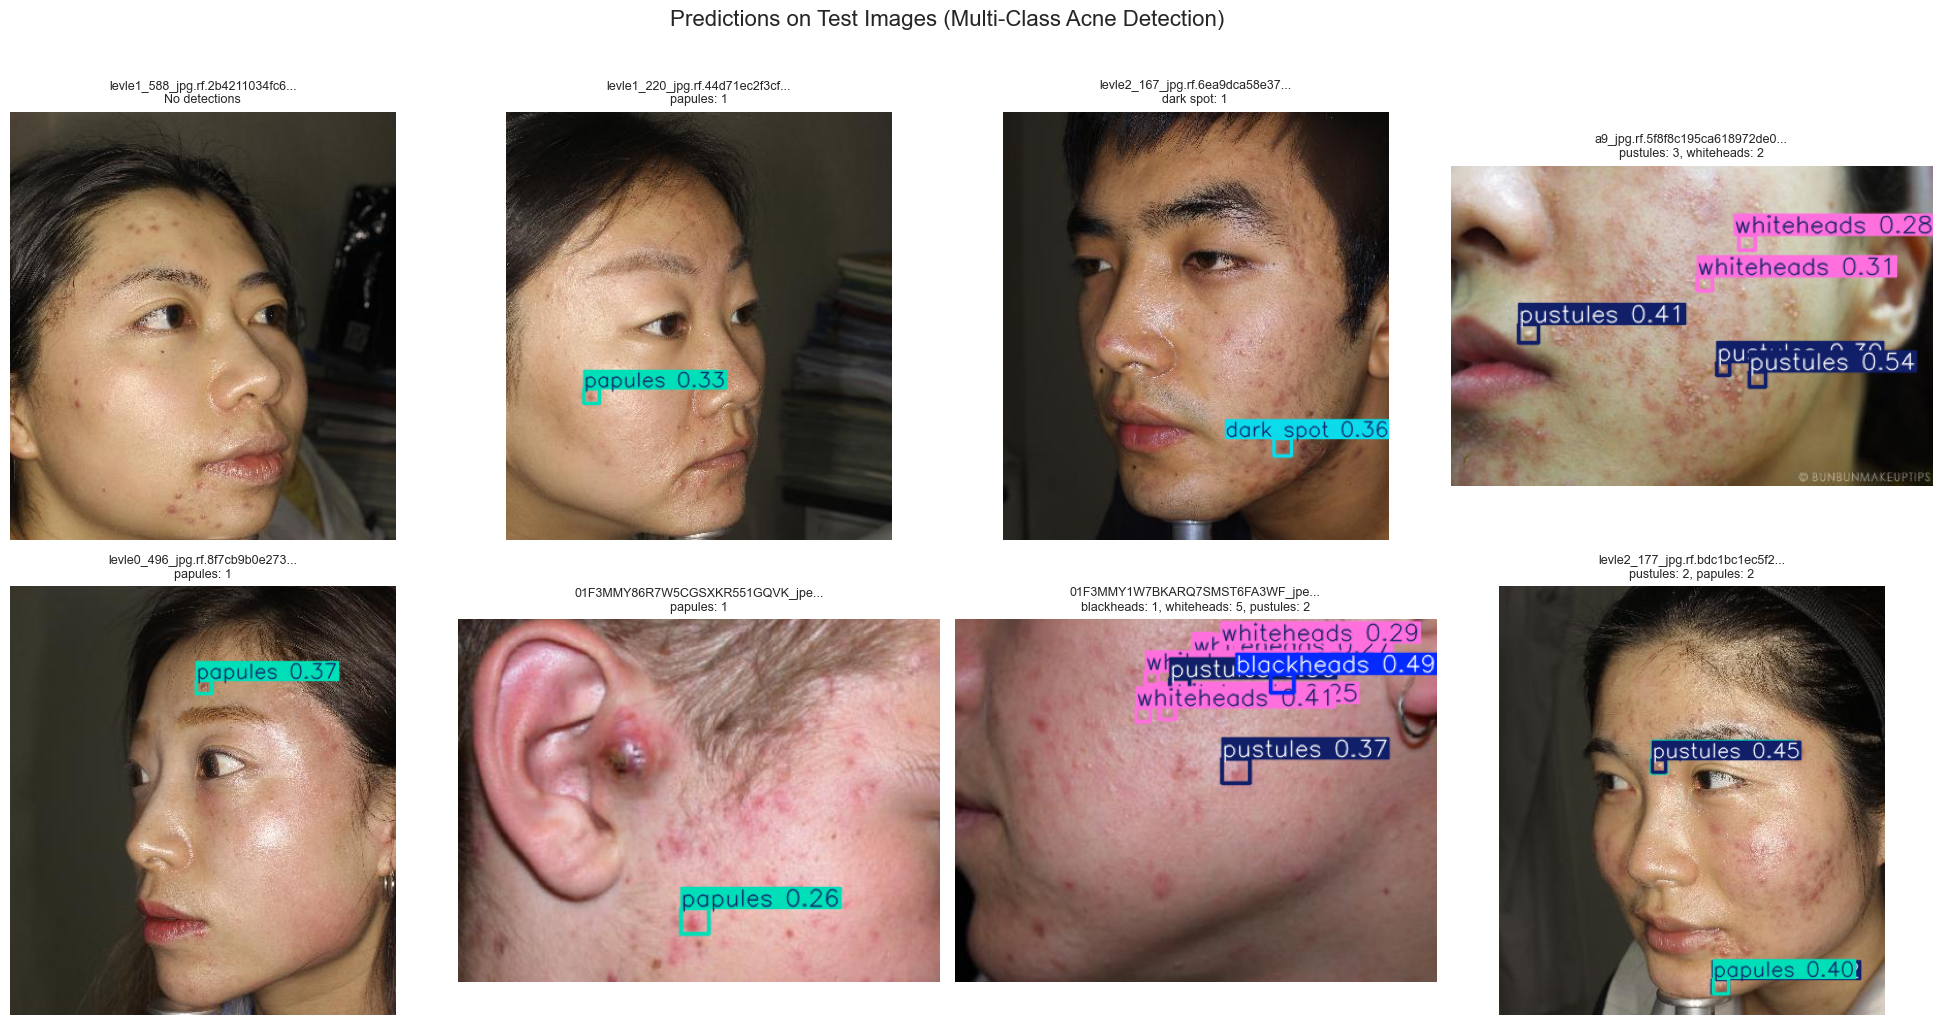

In [ ]:
# Visualize predictions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, (img_path, result) in enumerate(predictions):
    # Get annotated image
    annotated_img = result.plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Count detections per class
    if result.boxes is not None and len(result.boxes) > 0:
        detected_classes = result.boxes.cls.cpu().numpy().astype(int)
        class_counts = Counter(detected_classes)
        detection_info = []
        for cls_id, count in class_counts.items():
            cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
            detection_info.append(f"{cls_name}: {count}")
        title = f"{os.path.basename(img_path)[:30]}...\n" + ", ".join(detection_info)
    else:
        title = f"{os.path.basename(img_path)[:30]}...\nNo detections"
    
    axes[i].imshow(annotated_img_rgb)
    axes[i].axis('off')
    axes[i].set_title(title, fontsize=9)

plt.suptitle('Predictions on Test Images (Multi-Class Acne Detection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


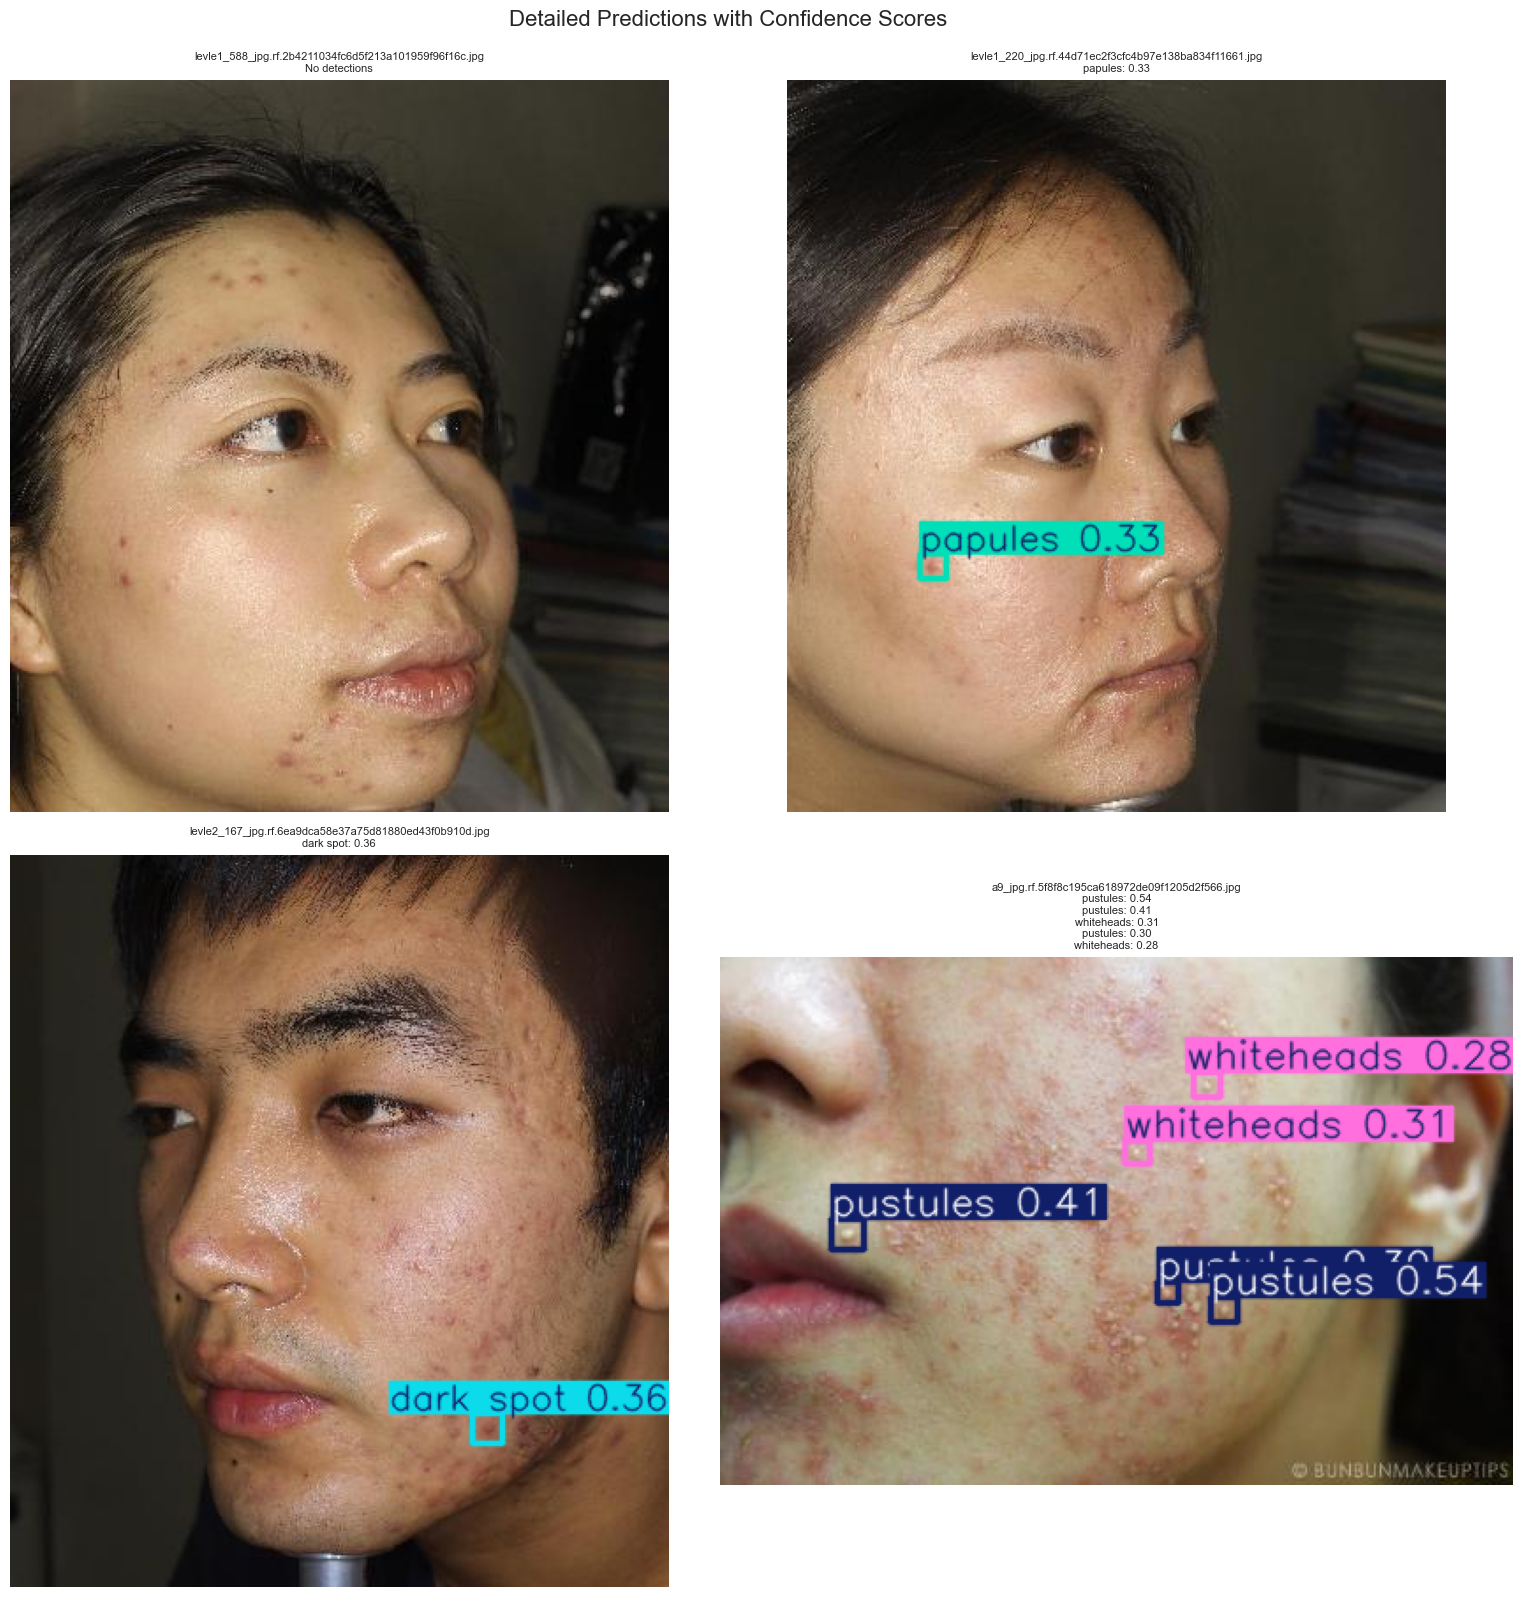

In [ ]:
# Detailed inference với confidence scores
def visualize_detections_detailed(img_path, result, class_names, ax):
    """Visualize detections with detailed information"""
    # Get annotated image
    annotated_img = result.plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(annotated_img_rgb)
    ax.axis('off')
    
    # Get detection details
    if result.boxes is not None and len(result.boxes) > 0:
        boxes = result.boxes
        detections_info = []
        
        for box in boxes:
            cls_id = int(box.cls.cpu().numpy()[0])
            conf = float(box.conf.cpu().numpy()[0])
            cls_name = class_names[cls_id] if cls_id < len(class_names) else f"Class {cls_id}"
            detections_info.append(f"{cls_name}: {conf:.2f}")
        
        title = f"{os.path.basename(img_path)}\n" + "\n".join(detections_info[:5])  # Show first 5
        if len(detections_info) > 5:
            title += f"\n... and {len(detections_info) - 5} more"
    else:
        title = f"{os.path.basename(img_path)}\nNo detections"
    
    ax.set_title(title, fontsize=8)

# Visualize với chi tiết
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.ravel()

for i in range(min(4, len(predictions))):
    img_path, result = predictions[i]
    visualize_detections_detailed(img_path, result, class_names, axes[i])

plt.suptitle('Detailed Predictions with Confidence Scores', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()
